In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/elikplim/concrete-compressive-strength-data-set/concrete_data.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

In [6]:
df=pd.read_csv('/kaggle/input/datasets/elikplim/concrete-compressive-strength-data-set/concrete_data.csv')

In [7]:
df.head()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [10]:
df.isnull().sum()

cement                           0
blast_furnace_slag               0
fly_ash                          0
water                            0
superplasticizer                 0
coarse_aggregate                 0
fine_aggregate                   0
age                              0
concrete_compressive_strength    0
dtype: int64

In [11]:
df.describe()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [9]:
df.skew

<bound method DataFrame.skew of       cement  blast_furnace_slag  fly_ash  water  superplasticizer  \
0      540.0                 0.0      0.0  162.0               2.5   
1      540.0                 0.0      0.0  162.0               2.5   
2      332.5               142.5      0.0  228.0               0.0   
3      332.5               142.5      0.0  228.0               0.0   
4      198.6               132.4      0.0  192.0               0.0   
...      ...                 ...      ...    ...               ...   
1025   276.4               116.0     90.3  179.6               8.9   
1026   322.2                 0.0    115.6  196.0              10.4   
1027   148.5               139.4    108.6  192.7               6.1   
1028   159.1               186.7      0.0  175.6              11.3   
1029   260.9               100.5     78.3  200.6               8.6   

      coarse_aggregate  fine_aggregate   age  concrete_compressive_strength  
0               1040.0            676.0   28     

In [21]:
# Before Data Skewness

for col in df.columns:
    print(col,df[col].skew())

cement 0.509481178871773
blast_furnace_slag 0.8007168956061772
fly_ash 0.5373539058066844
water 0.07462838428549402
superplasticizer 0.9072025748672465
coarse_aggregate -0.04021974481106706
fine_aggregate  -0.25300959769707576
age 3.26917740063459
concrete_compressive_strength 0.416977288410718


In [22]:
df.corr(numeric_only=True)

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
cement,1.000000,-0.275216,-0.397467,-0.081587,0.092386,-0.109349,-0.222718,0.081946,0.497832
blast_furnace_slag,-0.275216,1.000000,-0.323580,0.107252,0.043270,-0.283999,-0.281603,-0.044246,0.134829
fly_ash,-0.397467,-0.323580,1.000000,-0.256984,0.377503,-0.009961,0.079108,-0.154371,-0.105755
water,-0.081587,0.107252,-0.256984,1.000000,-0.657533,-0.182294,-0.450661,0.277618,-0.289633
superplasticizer,0.092386,0.043270,0.377503,-0.657533,1.000000,-0.265999,0.222691,-0.192700,0.366079
coarse_aggregate,-0.109349,-0.283999,-0.009961,-0.182294,-0.265999,1.000000,-0.178481,-0.003016,-0.164935
fine_aggregate,-0.222718,-0.281603,0.079108,-0.450661,0.222691,-0.178481,1.000000,-0.156095,-0.167241
age,0.081946,-0.044246,-0.154371,0.277618,-0.192700,-0.003016,-0.156095,1.000000,0.328873
concrete_compressive_strength,0.497832,0.134829,-0.105755,-0.289633,0.366079,-0.164935,-0.167241,0.328873,1.000000


In [66]:

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [30]:
x=df.drop('concrete_compressive_strength',axis=1)
y=df['concrete_compressive_strength']

In [31]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

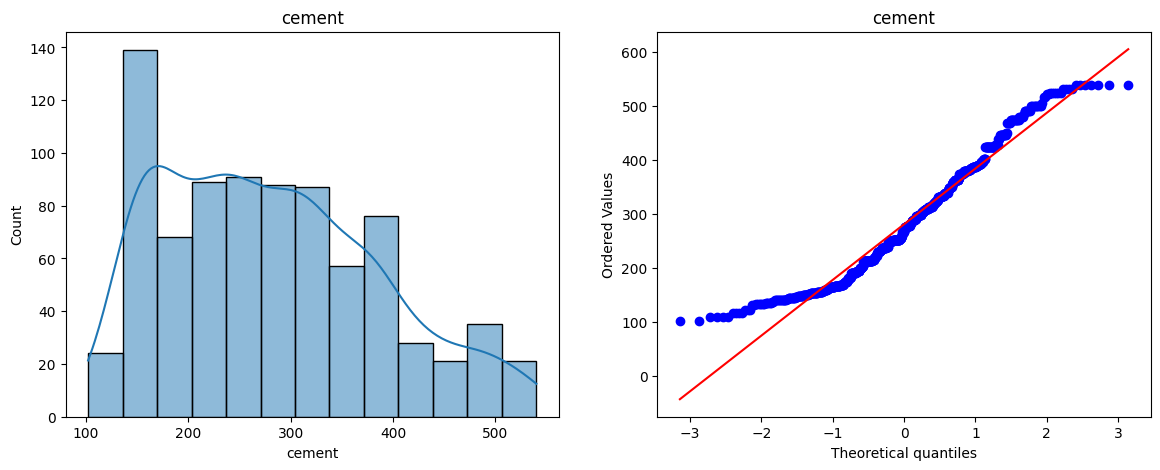

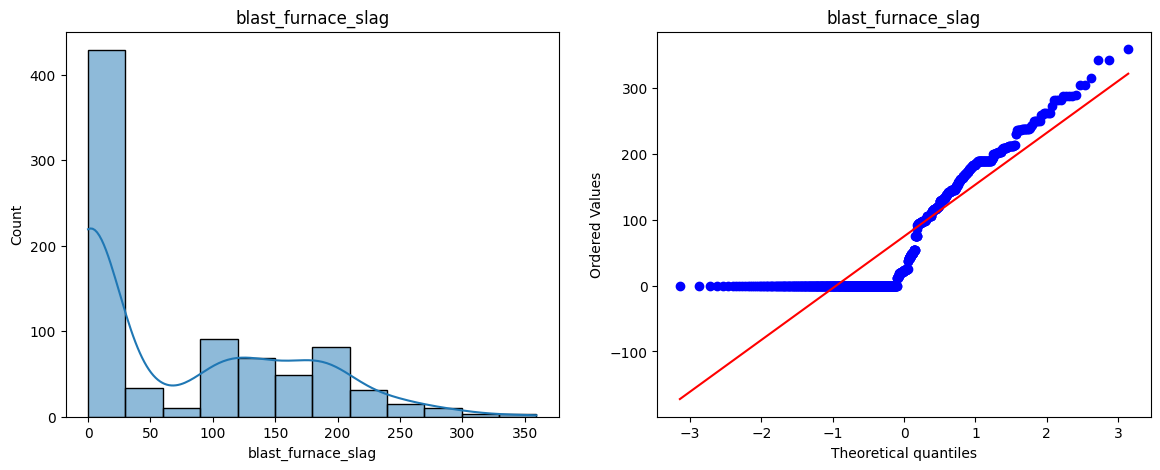

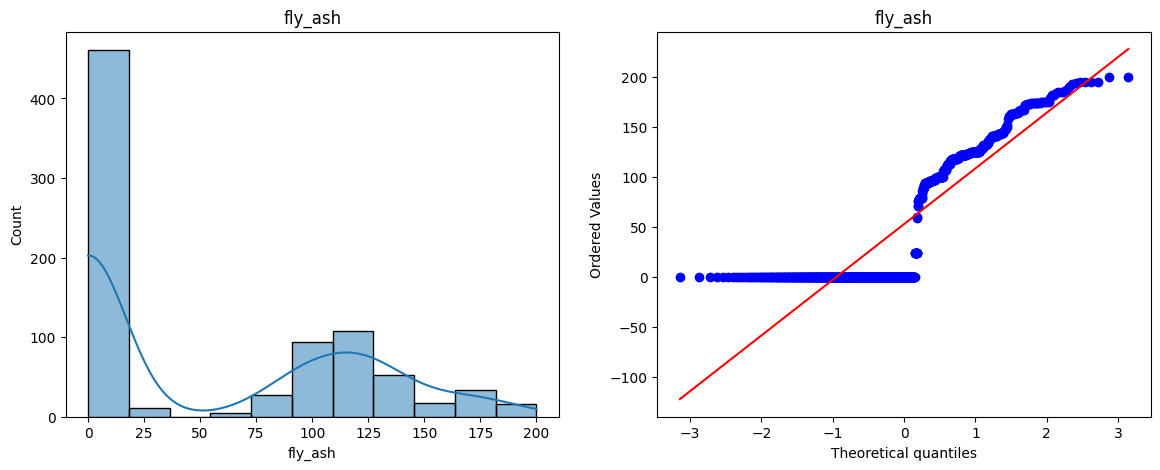

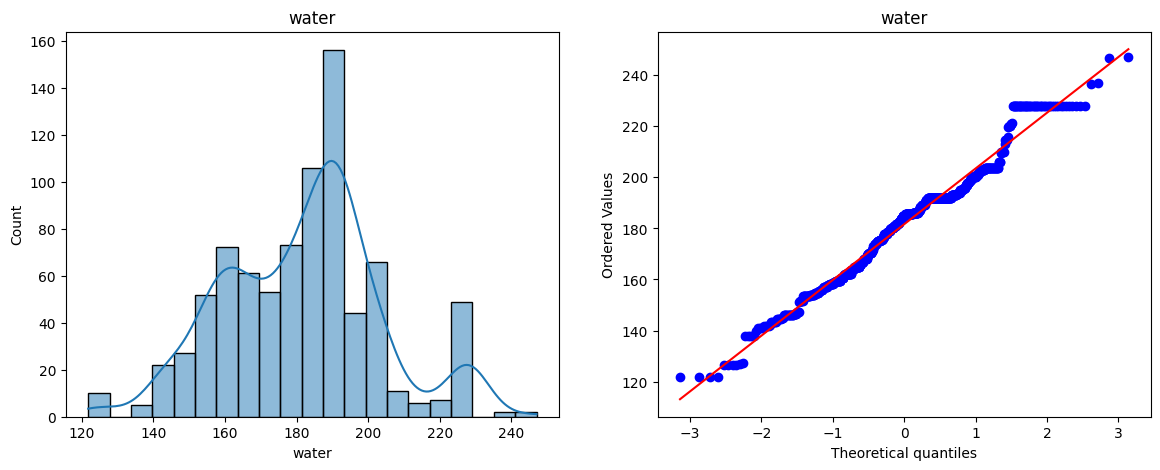

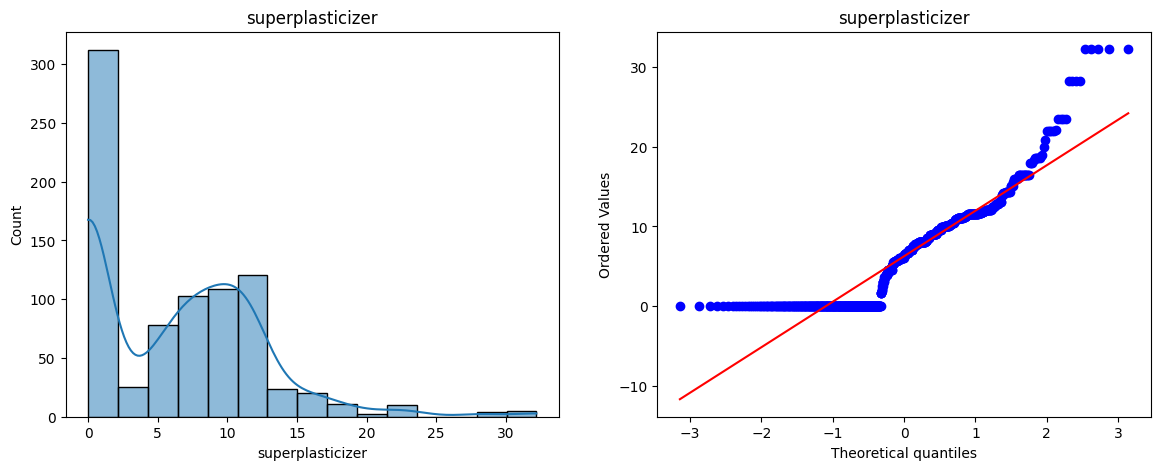

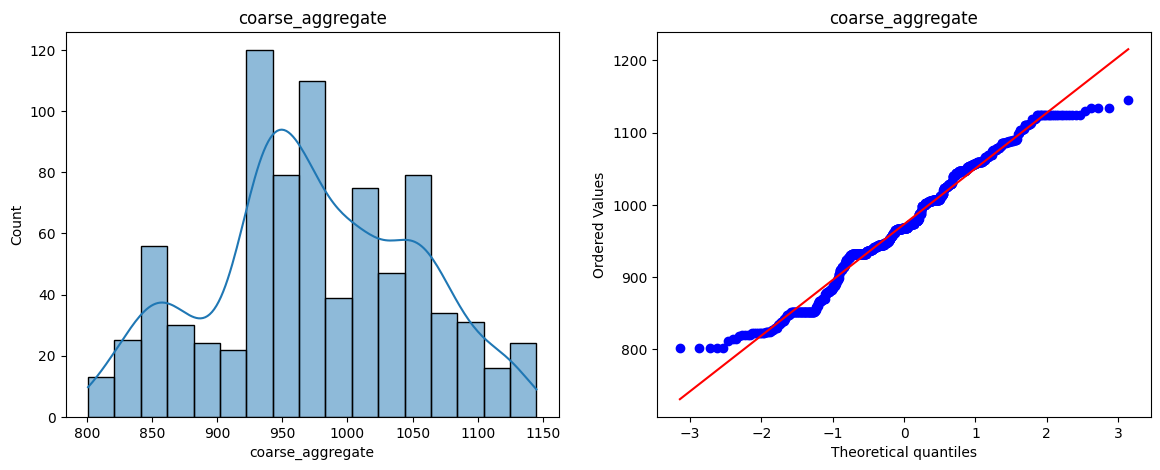

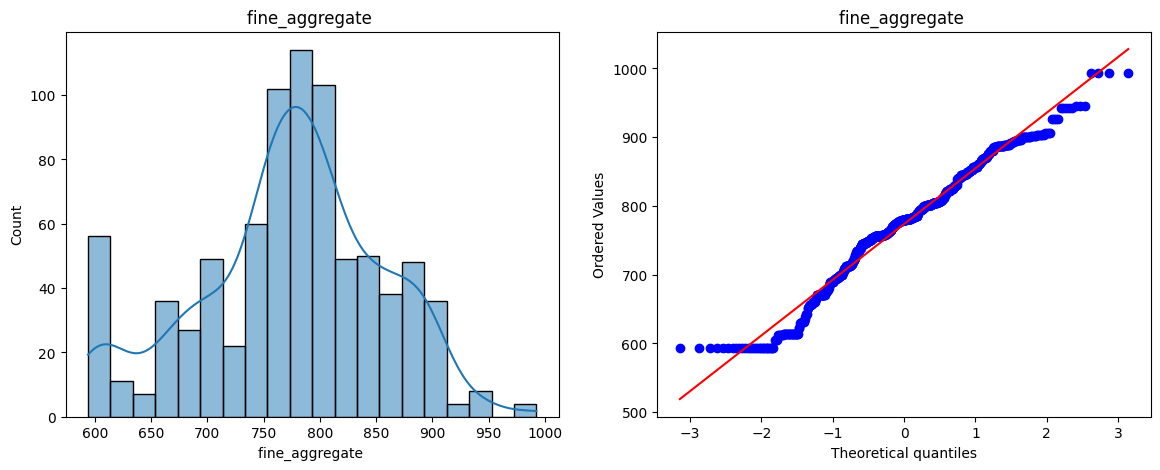

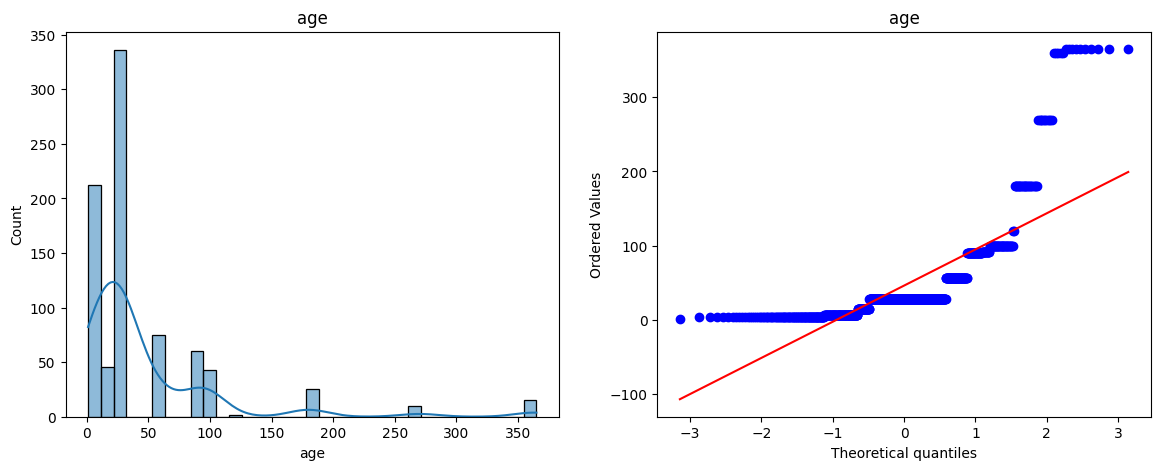

In [43]:
for col in x_train.columns:
    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    sns.histplot(x_train[col],kde=True)
    plt.title(col)

    plt.subplot(1,2,2)
    stats.probplot(x_train[col], dist="norm", plot=plt)
    plt.title(col)
   

# Power Transform

In [51]:
pt=PowerTransformer(method='box-cox')

x_train_transformed=pt.fit_transform(x_train+0.000001)
x_test_transformed=pt.transform(x_test+0.0000001)

data_transformed=pd.DataFrame({
    'col':x_train.columns,
    'Box-Cox Score': pt.lambdas_
})

In [52]:
data_transformed

,col,Box-Cox Score
0,cement,0.183315
1,blast_furnace_slag,0.023672
2,fly_ash,-0.038957
3,water,0.743640
4,superplasticizer,0.096667
5,coarse_aggregate,1.154481
6,fine_aggregate,1.937226
7,age,0.050246


# Before Power Transform

In [56]:
#  Model Building And Predictiong

lr=LinearRegression()

lr.fit(x_train,y_train)


LinearRegression()

In [57]:
pred=lr.predict(x_test)

In [60]:
print(r2_score(y_test,pred))

0.6069086269006541


In [71]:
scores = cross_val_score(lr, x_train, y_train, cv=5)
print(scores)
print(scores.mean())

[0.58577823 0.6307395  0.63978403 0.59565353 0.58396975]
0.6071850083982954


# After Power transform

In [61]:
lrn=LinearRegression()

lrn.fit(x_train_transformed,y_train)

LinearRegression()

In [62]:
pred_new=lrn.predict(x_test_transformed)

In [63]:
print(r2_score(y_test,pred_new))

0.8235101885509626


In [73]:
scores=cross_val_score(lrn,x_train_transformed,y_train,cv=5)
print(scores)
print(scores.mean())

[0.79178584 0.80067343 0.81677875 0.77498219 0.77697797]
0.7922396354026713


# Yolo Johnson Transformer

In [89]:
pty=PowerTransformer()

x_train_transformed1=pty.fit_transform(x_train)
x_test_transformed1=pty.transform(x_test)

data_transformed1=pd.DataFrame({
    'col':x_train.columns,
    'Yolo Score': pty.lambdas_
})

In [91]:
data_transformed1

,col,Yolo Score
0,cement,0.180674
1,blast_furnace_slag,0.015344
2,fly_ash,-0.160707
3,water,0.742180
4,superplasticizer,0.243187
5,coarse_aggregate,1.154738
6,fine_aggregate,1.938527
7,age,0.004181


In [92]:
data_transformed

,col,Box-Cox Score
0,cement,0.180674
1,blast_furnace_slag,0.015344
2,fly_ash,-0.160707
3,water,0.742180
4,superplasticizer,0.243187
5,coarse_aggregate,1.154738
6,fine_aggregate,1.938527
7,age,0.004181


In [93]:
l=LinearRegression()
l.fit(x_train,y_train)

LinearRegression()

In [94]:
predd=l.predict(x_test)

In [100]:
print(r2_score(y_test,predd))

0.6069086269006541


In [96]:
lrr=LinearRegression()
lrr.fit(x_train_transformed1,y_train)

LinearRegression()

In [98]:
p=lrr.predict(x_test_transformed1)

In [99]:
print(r2_score(y_test,p))

0.8216131529928065
